# 01. Focos de Calor — INPE Queimadas + NASA FIRMS VIIRS

Extração e validação cruzada dos registros históricos de focos de incêndio a partir de **duas fontes independentes**:

- **INPE Queimadas (AQUA_M-T):** GeoServer WFS — resolução ~1 km (MODIS)  
  https://terrabrasilis.dpi.inpe.br/queimadas/portal/

- **NASA FIRMS VIIRS:** API histórica (Standard Processing) — resolução ~375 m  
  https://firms.modaps.eosdis.nasa.gov/api/ — satélites SNPP e NOAA-20

**Período:** 2023 completo

## 0. Dependências e configuração

In [ ]:
import io, calendar, os, urllib3
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from dotenv import load_dotenv

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
load_dotenv()

# INPE
DATA_DIR = Path('data/inpe_queimadas')
DATA_DIR.mkdir(parents=True, exist_ok=True)
INPE_WFS = 'https://terrabrasilis.dpi.inpe.br/queimadas/geoserver/ows'

# NASA FIRMS
FIRMS_KEY  = os.getenv('FIRMS_KEY', 'YOUR_MAP_KEY')
FIRMS_DIR  = Path('data/firms')
FIRMS_DIR.mkdir(parents=True, exist_ok=True)
FIRMS_BASE = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv'
BBOX_FIRMS = '-74.0,-33.8,-28.6,5.5'  # W,S,E,N — Brasil

ANO      = 2023
MESES_PT = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
CORES_BIOMA = {
    'Amazonia'      : '#2ca02c',
    'Cerrado'       : '#ff7f0e',
    'Caatinga'      : '#d62728',
    'Mata Atlantica': '#9467bd',
    'Pantanal'      : '#17becf',
    'Pampa'         : '#bcbd22',
}

print(f'FIRMS_KEY: {"*" * 8 + FIRMS_KEY[-4:] if FIRMS_KEY != "YOUR_MAP_KEY" else "NAO DEFINIDA"}')

## 1. Download INPE Queimadas (AQUA_M-T)

In [8]:
def download_inpe_mes(ano, mes, satelite='satref'):
# Baixa focos de um mes via GeoServer WFS com filtro CQL
    ultimo_dia = calendar.monthrange(ano, mes)[1]
    layer  = f'dados_abertos:focos_{ano}_br_{satelite}'
    filtro = f'data_pas BETWEEN {ano}-{mes:02d}-01 AND {ano}-{mes:02d}-{ultimo_dia}'
    arq    = DATA_DIR / f'inpe_focos_{ano}_{mes:02d}_{satelite}.csv'
    if arq.exists():
        print(f'  [cache] {arq.name} ({arq.stat().st_size/1024:.0f} KB)')
        return arq
    url = (
        f'{INPE_WFS}?SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature'
        f'&typeNames={layer}&outputFormat=csv'
        f'&CQL_FILTER={filtro}'
    )
    resp = requests.get(url, timeout=120, verify=False)
    resp.raise_for_status()
    arq.write_bytes(resp.content)
    print(f'  [ok] {arq.name} ({len(resp.content)/1024:.0f} KB)')
    return arq


print(f'Baixando focos {ANO} (satelite referencia)...')
arquivos = []
for mes in range(1, 13):
    try:
        arquivos.append(download_inpe_mes(ANO, mes))
    except Exception as e:
        print(f'  [erro] {ANO}-{mes:02d}: {e}')

print(f'Arquivos baixados: {len(arquivos)}/12')

Baixando focos 2023 (satelite referencia)...
  [cache] inpe_focos_2023_01_satref.csv (717 KB)
  [cache] inpe_focos_2023_02_satref.csv (582 KB)
  [cache] inpe_focos_2023_03_satref.csv (741 KB)
  [cache] inpe_focos_2023_04_satref.csv (676 KB)
  [cache] inpe_focos_2023_05_satref.csv (1507 KB)
  [cache] inpe_focos_2023_06_satref.csv (2469 KB)
  [cache] inpe_focos_2023_07_satref.csv (3984 KB)
  [cache] inpe_focos_2023_08_satref.csv (7929 KB)
  [cache] inpe_focos_2023_09_satref.csv (13172 KB)
  [cache] inpe_focos_2023_10_satref.csv (11205 KB)
  [cache] inpe_focos_2023_11_satref.csv (7636 KB)
  [cache] inpe_focos_2023_12_satref.csv (3265 KB)
Arquivos baixados: 12/12


## 2. Carregamento e inspeção — INPE Queimadas

In [9]:
# Carrega e consolida os arquivos mensais INPE
partes = []
for mes_num, arq in enumerate(arquivos, start=1):
    if arq is not None and arq.exists():
        parte = pd.read_csv(arq, low_memory=False)
        if 'mes' not in parte.columns:
            parte['mes'] = mes_num
        partes.append(parte)

df = pd.concat(partes, ignore_index=True)
df['data_pas']      = pd.to_datetime(df['data_pas'])
df['data_hora_gmt'] = pd.to_datetime(df['data_hora_gmt'], errors='coerce')
df['frp']           = pd.to_numeric(df['frp'],        errors='coerce')
df['risco_fogo']    = pd.to_numeric(df['risco_fogo'], errors='coerce')

print(f'Total de focos:  {len(df):,}')
print(f'Periodo:         {df["data_pas"].min().date()} a {df["data_pas"].max().date()}')
print(f'Colunas ({len(df.columns)}): {list(df.columns)}')
df.head(3)

Total de focos:  189,901
Periodo:         2023-01-01 a 2023-12-31
Colunas (24): ['FID', 'id_foco_bdq', 'foco_id', 'longitude', 'latitude', 'data_hora_gmt', 'data_pas', 'satelite', 'municipio', 'estado', 'pais', 'precipitacao', 'numero_dias_sem_chuva', 'risco_fogo', 'bioma', 'geometria', 'id_0', 'id_1', 'id_2', 'continente_id', 'vegetacao', 'grade_wrs', 'frp', 'mes']


,FID,id_foco_bdq,foco_id,longitude,latitude,data_hora_gmt,data_pas,satelite,municipio,estado,...,bioma,geometria,id_0,id_1,id_2,continente_id,vegetacao,grade_wrs,frp,mes
0,focos_2023_br_satref.fid--59e147b5_19cb3e3070f...,1615033233,9a03983d-e1b3-3df1-b5e6-0a4ca26e3548,-57.66138,-17.52869,2023-01-02 17:11:00,2023-01-02,AQUA_M-T,CÁCERES,MATO GROSSO,...,Pantanal,POINT (-17.52869 -57.66138),33,51,5102504,8,Floresta Ombrófila densa,227_072,82.4,1
1,focos_2023_br_satref.fid--59e147b5_19cb3e3070f...,1615033235,23953122-a8e4-3cd9-ac94-91aa2ad22ff4,-57.48255,-17.61373,2023-01-02 17:11:00,2023-01-02,AQUA_M-T,POCONÉ,MATO GROSSO,...,Pantanal,POINT (-17.61373 -57.48255),33,51,5106505,8,Floresta Ombrófila densa,227_072,63.7,1
2,focos_2023_br_satref.fid--59e147b5_19cb3e3070f...,1615033238,7067c6d1-9165-308c-a2c3-839d0f7c7925,-57.47493,-17.61592,2023-01-02 17:11:00,2023-01-02,AQUA_M-T,POCONÉ,MATO GROSSO,...,Pantanal,POINT (-17.61592 -57.47493),33,51,5106505,8,Floresta Ombrófila densa,227_072,101.4,1


## 3. Download — FIRMS VIIRS (opcional)

Validação cruzada com o sensor VIIRS a bordo dos satélites Suomi-NPP e NOAA-20 (~375 m, revisita diária).

In [10]:
def download_firms_ano(ano, source, bbox=BBOX_FIRMS, destino=FIRMS_DIR):
    """
    Baixa focos FIRMS para o ano completo via API historica (SP = Standard Processing).
    source: 'VIIRS_SNPP_SP' ou 'VIIRS_NOAA20_SP'
    Resolucao: ~375 m | Cobertura: global | Revisita: ~1x/dia por satelite

    A API limita a 10 dias por requisicao — itera em chunks e consolida num unico CSV.
    URL: /api/area/csv/{key}/{source}/{bbox}/{day_range}/{date_fim}
    """
    import datetime

    arq = destino / f'firms_{source}_{ano}.csv'
    if arq.exists():
        print(f'  [cache] {arq.name} ({arq.stat().st_size/1024:.0f} KB)')
        return arq
    if FIRMS_KEY == 'YOUR_MAP_KEY':
        print(f'  [aviso] FIRMS_KEY nao configurado — pule esta celula ou defina sua chave.')
        return None

    # Gera chunks de ate 5 dias cobrindo o ano inteiro
    inicio = datetime.date(ano, 1, 1)
    fim    = datetime.date(ano, 12, 31)
    chunks, d = [], inicio
    while d <= fim:
        d_fim = min(d + datetime.timedelta(days=4), fim)
        chunks.append((d, d_fim))
        d = d_fim + datetime.timedelta(days=1)

    partes = []
    for i, (d_ini, d_fim) in enumerate(chunks):
        days = (d_fim - d_ini).days + 1
        url  = f'{FIRMS_BASE}/{FIRMS_KEY}/{source}/{bbox}/{days}/{d_fim.strftime("%Y-%m-%d")}'
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        try:
            parte = pd.read_csv(io.BytesIO(resp.content))
            if len(parte) > 0:
                partes.append(parte)
        except Exception:
            pass  # chunk sem focos
        if (i + 1) % 15 == 0:
            print(f'  {i+1}/{len(chunks)} chunks ({(i+1)/len(chunks)*100:.0f}%)')

    if not partes:
        print(f'  [aviso] Nenhum dado retornado para {source} {ano}')
        return None

    df_out = pd.concat(partes, ignore_index=True).drop_duplicates()
    df_out.to_csv(arq, index=False)
    print(f'  [ok] {arq.name} ({arq.stat().st_size/1024:.0f} KB | {len(df_out):,} registros)')
    return arq


print(f'Baixando FIRMS VIIRS {ANO} (Standard Processing)...')
arq_snpp   = download_firms_ano(ANO, 'VIIRS_SNPP_SP')
arq_noaa20 = download_firms_ano(ANO, 'VIIRS_NOAA20_SP')
FIRMS_OK   = any(a is not None and a.exists() for a in [arq_snpp, arq_noaa20])
print(f'FIRMS disponivel: {FIRMS_OK}')

Baixando FIRMS VIIRS 2023 (Standard Processing)...
  [cache] firms_VIIRS_SNPP_SP_2023.csv (162333 KB)
  [cache] firms_VIIRS_NOAA20_SP_2023.csv (162178 KB)
FIRMS disponivel: True


In [11]:
# Carrega arquivos FIRMS em df_firms
if 'FIRMS_OK' not in dir():
    print('[aviso] Execute primeiro a celula de download FIRMS (secao 3).')
elif FIRMS_OK:
    partes_firms = []
    for arq, sat in [(arq_snpp, 'VIIRS_SNPP'), (arq_noaa20, 'VIIRS_NOAA20')]:
        if arq is not None and arq.exists():
            parte = pd.read_csv(arq, parse_dates=['acq_date'], low_memory=False)
            parte['satelite_firms'] = sat
            parte['mes'] = parte['acq_date'].dt.month
            partes_firms.append(parte)
    df_firms = pd.concat(partes_firms, ignore_index=True)
    print(f'FIRMS total:  {len(df_firms):,} deteccoes')
    print(df_firms['satelite_firms'].value_counts().to_string())
else:
    df_firms = None
    print('FIRMS nao disponivel — pulando validacao cruzada.')

FIRMS total:  4,068,421 deteccoes
satelite_firms
VIIRS_SNPP      2059983
VIIRS_NOAA20    2008438


## 4. Validação cruzada INPE × FIRMS VIIRS

Compara as duas fontes em três dimensões:
1. **Séries temporais diárias** — coerência sazonal entre INPE e VIIRS
2. **Distribuição do FRP** — diferença de sensibilidade entre MODIS 1 km e VIIRS 375 m
3. **Totais mensais** — magnitude relativa das detecções por satélite

In [ ]:
if FIRMS_OK:
    from scipy import stats

    # --- Series diarias ---
    inpe_diario = df.groupby('data_pas').size().rename('INPE_AQUA')
    snpp_diario = (df_firms[df_firms['satelite_firms'] == 'VIIRS_SNPP']
                   .groupby('acq_date').size().rename('VIIRS_SNPP'))
    noaa_diario = (df_firms[df_firms['satelite_firms'] == 'VIIRS_NOAA20']
                   .groupby('acq_date').size().rename('VIIRS_NOAA20'))

    comp = (inpe_diario.to_frame()
            .join(snpp_diario, how='outer')
            .join(noaa_diario, how='outer')
            .fillna(0).astype(int))

    # Correlacao INPE x VIIRS_SNPP (mesmo numero de satelites: 1 x 1)
    merged = comp[['INPE_AQUA', 'VIIRS_SNPP']].dropna()
    r, p = stats.pearsonr(merged['INPE_AQUA'], merged['VIIRS_SNPP'])

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
    fig.suptitle(f'Validacao Cruzada: INPE AQUA vs FIRMS VIIRS — {ANO}',
                 fontsize=13, fontweight='bold')

    # 1. Series temporais diarias
    ax = axes[0]
    ax.plot(comp.index, comp['INPE_AQUA'],  label='INPE AQUA_M-T (1 sat., ~1 km)',
            color='#d62728', linewidth=0.9, alpha=0.9)
    if 'VIIRS_SNPP' in comp.columns:
        ax.plot(comp.index, comp['VIIRS_SNPP'], label=f'FIRMS VIIRS SNPP (1 sat., ~375 m)  r={r:.3f}',
                color='#1f77b4', linewidth=0.8, alpha=0.8)
    if 'VIIRS_NOAA20' in comp.columns:
        ax.plot(comp.index, comp['VIIRS_NOAA20'], label='FIRMS VIIRS NOAA-20 (1 sat., ~375 m)',
                color='#ff7f0e', linewidth=0.8, alpha=0.8)
    ax.set_ylabel('Focos/dia')
    ax.set_title('Series Temporais Diarias')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # 2. Distribuicao FRP (filtra FRP invalido em ambas as fontes)
    ax = axes[1]
    frp_inpe  = df.loc[df['frp'] > 0, 'frp']
    frp_firms = df_firms.loc[df_firms['frp'] > 0, 'frp']
    ax.hist(frp_inpe,  bins=80, log=True, alpha=0.6, density=True,
            label=f'INPE AQUA  (n={len(frp_inpe):,})', color='#d62728')
    ax.hist(frp_firms, bins=80, log=True, alpha=0.6, density=True,
            label=f'FIRMS VIIRS (n={len(frp_firms):,})', color='#1f77b4')
    ax.set_xlabel('FRP (MW)'); ax.set_ylabel('Densidade (log)')
    ax.set_title('Distribuicao do FRP — apenas valores validos (FRP > 0)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

    # 3. Totais mensais por satelite (comparacao justa: 1 sat. por barra)
    ax = axes[2]
    inpe_mens = df.groupby('mes').size().reindex(range(1, 13), fill_value=0)
    snpp_mens = (df_firms[df_firms['satelite_firms'] == 'VIIRS_SNPP']
                 .groupby('mes').size().reindex(range(1, 13), fill_value=0))
    noaa_mens = (df_firms[df_firms['satelite_firms'] == 'VIIRS_NOAA20']
                 .groupby('mes').size().reindex(range(1, 13), fill_value=0))
    x = np.arange(1, 13); w = 0.27
    ax.bar(x - w, inpe_mens.values,  width=w, label='INPE AQUA_M-T',    color='#d62728', alpha=0.85, edgecolor='white')
    ax.bar(x,     snpp_mens.values,  width=w, label='FIRMS VIIRS SNPP',  color='#1f77b4', alpha=0.85, edgecolor='white')
    ax.bar(x + w, noaa_mens.values,  width=w, label='FIRMS VIIRS NOAA-20', color='#ff7f0e', alpha=0.85, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(MESES_PT, fontsize=8)
    ax.set_ylabel('Total de focos')
    ax.set_title('Totais Mensais por Satelite (comparacao 1 a 1)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig(FIRMS_DIR / f'fig_crossval_inpe_firms_{ANO}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Resumo comparativo
    print(f'Resumo comparativo {ANO}:')
    print(f'  {"Fonte":<28} {"Focos":>10}  {"FRP med (MW)":>14}  {"FRP max (MW)":>14}')
    print(f'  {"-"*68}')
    print(f'  {"INPE AQUA_M-T":<28} {len(df):>10,}  {frp_inpe.median():>14.1f}  {frp_inpe.max():>14.1f}')
    print(f'  {"FIRMS VIIRS SNPP":<28} {snpp_mens.sum():>10,}  {df_firms.loc[(df_firms["satelite_firms"]=="VIIRS_SNPP") & (df_firms["frp"]>0), "frp"].median():>14.1f}  {df_firms.loc[(df_firms["satelite_firms"]=="VIIRS_SNPP") & (df_firms["frp"]>0), "frp"].max():>14.1f}')
    print(f'  {"FIRMS VIIRS NOAA-20":<28} {noaa_mens.sum():>10,}  {df_firms.loc[(df_firms["satelite_firms"]=="VIIRS_NOAA20") & (df_firms["frp"]>0), "frp"].median():>14.1f}  {df_firms.loc[(df_firms["satelite_firms"]=="VIIRS_NOAA20") & (df_firms["frp"]>0), "frp"].max():>14.1f}')
    print(f'\n  Correlacao de Pearson INPE x VIIRS SNPP (diario): r = {r:.4f}  (p = {p:.2e})')
    print(f'  Razao SNPP/INPE: {snpp_mens.sum()/len(df):.1f}x  |  NOAA-20/INPE: {noaa_mens.sum()/len(df):.1f}x')
else:
    print('[aviso] FIRMS nao carregado — configure FIRMS_KEY para habilitar a validacao cruzada.')

## 5. Visualizações — INPE Queimadas

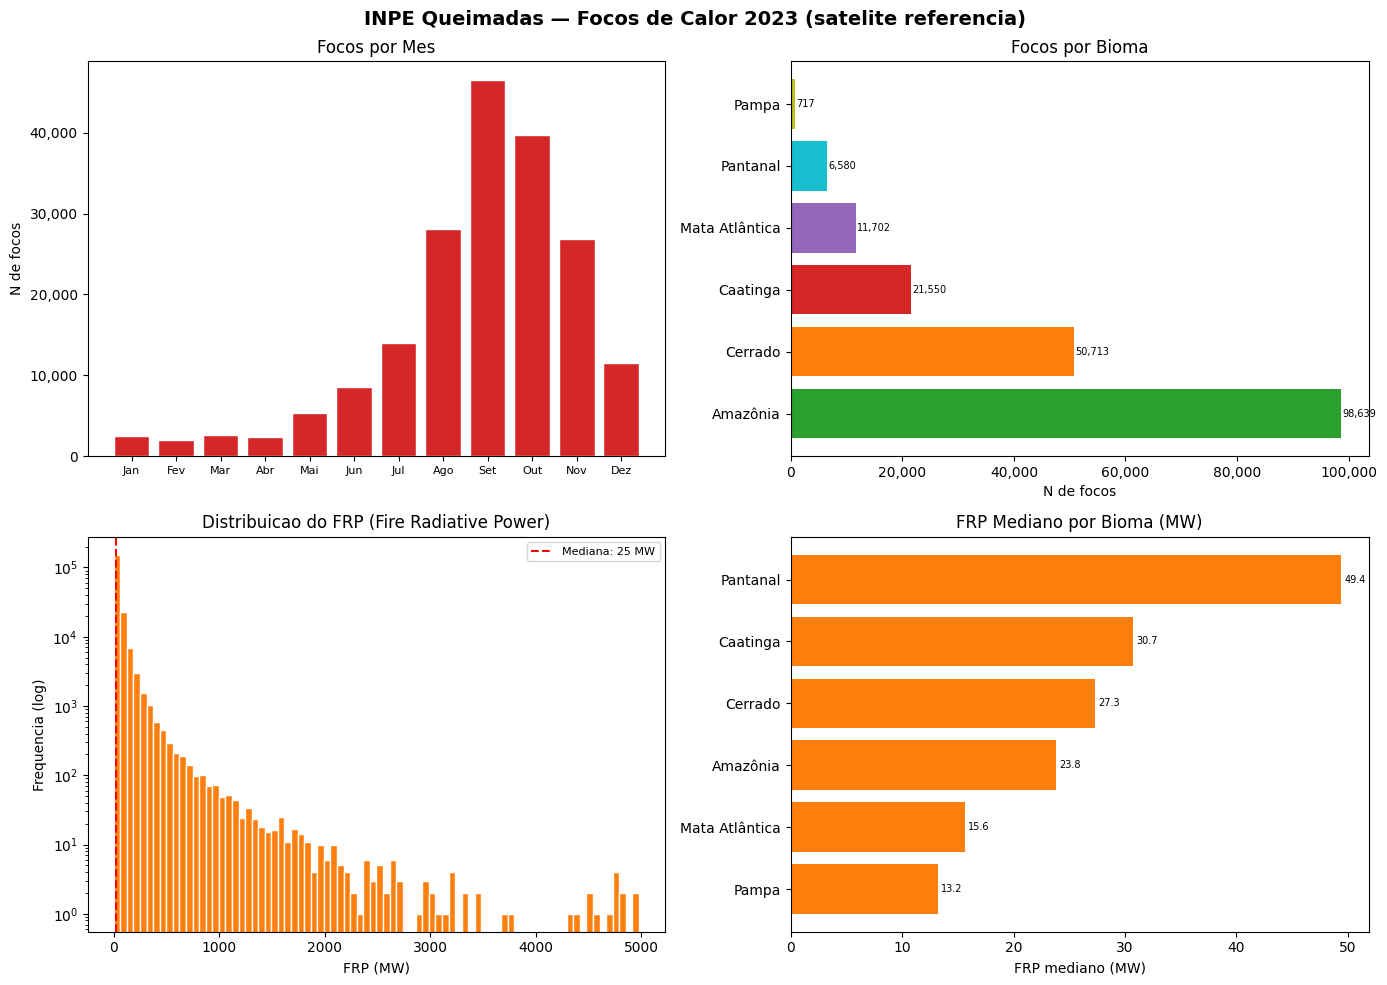

In [13]:
MESES_PT = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
CORES_BIOMA = {'Amazonia':'#2ca02c','Cerrado':'#ff7f0e','Caatinga':'#d62728',
               'Mata Atlantica':'#9467bd','Pantanal':'#17becf','Pampa':'#bcbd22'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'INPE Queimadas — Focos de Calor {ANO} (satelite referencia)', fontsize=14, fontweight='bold')

# Focos por mes
cnt_mes = df['mes'].value_counts().sort_index()
axes[0,0].bar(cnt_mes.index, cnt_mes.values, color='#d62728', edgecolor='white')
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(MESES_PT, fontsize=8)
axes[0,0].set_title('Focos por Mes')
axes[0,0].set_ylabel('N de focos')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Focos por bioma
cnt_bioma = df['bioma'].value_counts()
cores = list(CORES_BIOMA.values())[:len(cnt_bioma)]
axes[0,1].barh(cnt_bioma.index, cnt_bioma.values, color=cores)
axes[0,1].set_title('Focos por Bioma')
axes[0,1].set_xlabel('N de focos')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, v in enumerate(cnt_bioma.values):
    axes[0,1].text(v+200, i, f'{v:,}', va='center', fontsize=7)

# Distribuicao FRP
frp = df['frp'].dropna()
axes[1,0].hist(frp, bins=80, color='#ff7f0e', edgecolor='white', log=True)
axes[1,0].axvline(frp.median(), color='red', linestyle='--', label=f'Mediana: {frp.median():.0f} MW')
axes[1,0].set_title('Distribuicao do FRP (Fire Radiative Power)')
axes[1,0].set_xlabel('FRP (MW)'); axes[1,0].set_ylabel('Frequencia (log)')
axes[1,0].legend(fontsize=8)

# FRP mediano por bioma
frp_bioma = df.groupby('bioma')['frp'].median().sort_values()
axes[1,1].barh(frp_bioma.index, frp_bioma.values, color='#ff7f0e')
axes[1,1].set_title('FRP Mediano por Bioma (MW)')
axes[1,1].set_xlabel('FRP mediano (MW)')
for i, v in enumerate(frp_bioma.values):
    axes[1,1].text(v+0.3, i, f'{v:.1f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(DATA_DIR / f'fig_painel_{ANO}.png', dpi=150, bbox_inches='tight')
plt.show()

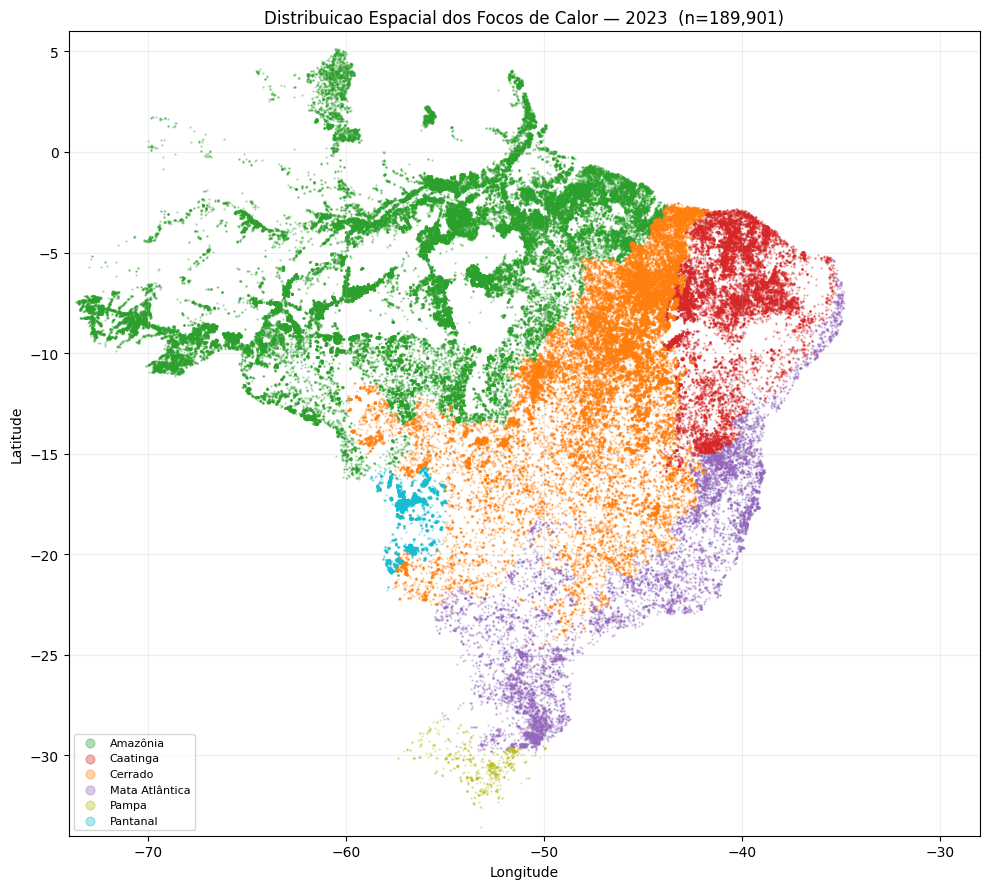

In [14]:
def normaliza(s):
    import unicodedata
    return unicodedata.normalize('NFKD', s).encode('ascii', errors='ignore').decode()

CORES_BIOMA = {'Amazonia':'#2ca02c','Cerrado':'#ff7f0e','Caatinga':'#d62728',
               'Mata Atlantica':'#9467bd','Pantanal':'#17becf','Pampa':'#bcbd22'}

fig, ax = plt.subplots(figsize=(10, 9))
for bioma, grupo in df.groupby('bioma'):
    cor = CORES_BIOMA.get(normaliza(bioma), '#aaaaaa')
    ax.scatter(grupo['longitude'], grupo['latitude'],
               s=0.4, alpha=0.35, color=cor, label=bioma, rasterized=True)

ax.set_xlim(-74, -28); ax.set_ylim(-34, 6)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Distribuicao Espacial dos Focos de Calor — {ANO}  (n={len(df):,})')
ax.legend(markerscale=10, fontsize=8, loc='lower left', framealpha=0.8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(DATA_DIR / f'fig_mapa_{ANO}.png', dpi=150, bbox_inches='tight')
plt.show()

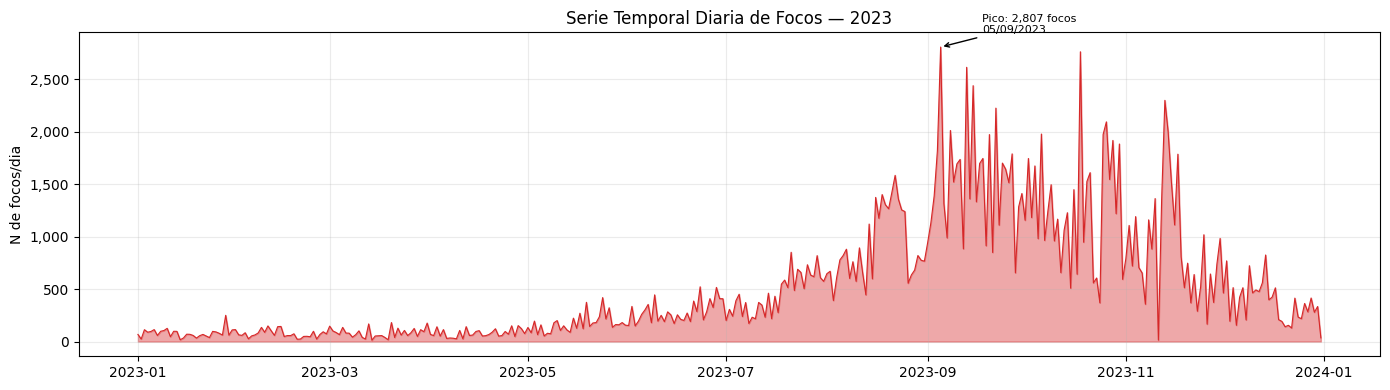

In [15]:
# Serie temporal diaria
serie = df.groupby('data_pas').size().reset_index(name='focos')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(serie['data_pas'], serie['focos'], alpha=0.4, color='#d62728')
ax.plot(serie['data_pas'], serie['focos'], color='#d62728', linewidth=0.8)

pico = serie.loc[serie['focos'].idxmax()]
ax.annotate(
    f"Pico: {int(pico['focos']):,} focos\n{pico['data_pas'].strftime('%d/%m/%Y')}",
    xy=(pico['data_pas'], pico['focos']),
    xytext=(30, 10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'), fontsize=8
)
ax.set_title(f'Serie Temporal Diaria de Focos — {ANO}')
ax.set_ylabel('N de focos/dia')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(DATA_DIR / f'fig_serie_{ANO}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Estatísticas resumo e exportação

In [ ]:
print('Estatisticas INPE Queimadas')
print(f'Total de focos:          {len(df):>10,}')

frp_valido   = df.loc[df['frp'] > 0, 'frp']
risco_valido = df.loc[df['risco_fogo'] > 0, 'risco_fogo']   # exclui -999 e valores<=0
dias_validos = df.loc[df['numero_dias_sem_chuva'] >= 0, 'numero_dias_sem_chuva']

print(f'Focos com FRP valido:    {frp_valido.count():>10,}')
print(f'FRP mediano (MW):        {frp_valido.median():>10.1f}')
print(f'FRP maximo (MW):         {frp_valido.max():>10.1f}')
print(f'Risco fogo medio:        {risco_valido.mean():>10.3f}  ({risco_valido.count():,} validos)')
print(f'Dias sem chuva (media):  {dias_validos.mean():>10.1f}  ({dias_validos.count():,} validos)')
print()

resumo = df.groupby('bioma').agg(
    focos=('foco_id','count'),
    frp_mediano=('frp',                  lambda x: x[x > 0].median()),
    risco_medio=('risco_fogo',           lambda x: x[x > 0].mean()),
    dias_sem_chuva=('numero_dias_sem_chuva', lambda x: x[x >= 0].mean())
).sort_values('focos', ascending=False)
resumo['pct'] = (resumo['focos'] / resumo['focos'].sum() * 100).round(1)
print('Por bioma:')
print(resumo.to_string())

# Exporta INPE consolidado
out_inpe = DATA_DIR / f'inpe_focos_{ANO}_consolidado.csv'
df.to_csv(out_inpe, index=False)
print(f'\nDataset INPE salvo: {out_inpe} ({out_inpe.stat().st_size/1e6:.1f} MB)')

# Exporta FIRMS se disponivel
if FIRMS_OK and df_firms is not None:
    print()
    print('Estatisticas FIRMS VIIRS')
    print(f'Total de deteccoes:      {len(df_firms):>10,}')
    print(f'FRP mediano (MW):        {df_firms["frp"].median():>10.1f}')
    print(f'FRP maximo (MW):         {df_firms["frp"].max():>10.1f}')
    print(f'Razao VIIRS/INPE:        {len(df_firms)/len(df):>10.1f}x')

    out_firms = FIRMS_DIR / f'firms_viirs_{ANO}.csv'
    df_firms.to_csv(out_firms, index=False)
    print(f'\nDataset FIRMS salvo: {out_firms} ({out_firms.stat().st_size/1e6:.1f} MB)')

print()
print('Arquivos disponiveis para os proximos notebooks:')
print(f'  {out_inpe}')
if FIRMS_OK and df_firms is not None:
    print(f'  {out_firms}')